<a href="https://colab.research.google.com/github/FC-Andrade/Syndecan_4-Ag73/blob/main/AN%C3%81LISE_DE_RMSD%2C_RMSF_E_RG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# ANÁLISE DE RMSD E RMSF (Triplicatas)
# Syndecan-4 Apo x Complexo AG73
# ============================================================
!pip install MDAnalysis biopython seaborn matplotlib > /dev/null

import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
from MDAnalysis.analysis.rms import RMSF
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files
import io

sns.set(style="ticks", font_scale=1.1)


In [ ]:
# ------------------------------------------------------------
# 2. Upload dos arquivos
# ------------------------------------------------------------
print("📂 Faça upload dos arquivos:")
print("Exemplo: apo.pdb, apo_rep1.xtc, apo_rep2.xtc, apo_rep3.xtc, AG73.pdb, AG73_rep1.xtc, AG73_rep2.xtc, AG73_rep3.xtc")

uploaded = files.upload()
files_list = list(uploaded.keys())

📂 Faça upload dos arquivos:
Exemplo: apo.pdb, apo_rep1.xtc, apo_rep2.xtc, apo_rep3.xtc, AG73.pdb, AG73_rep1.xtc, AG73_rep2.xtc, AG73_rep3.xtc


Saving AG73Synd1.pdb to AG73Synd1.pdb
Saving AG73Synd1.xtc to AG73Synd1.xtc
Saving AG73Synd2.xtc to AG73Synd2.xtc
Saving AG73Synd3.xtc to AG73Synd3.xtc
Saving APO1.pdb to APO1.pdb
Saving APO1.xtc to APO1.xtc
Saving APO2.xtc to APO2.xtc
Saving APO3.xtc to APO3.xtc


In [ ]:
# ------------------------------------------------------------
# Função para detectar PDB único e múltiplas trajetórias
# ------------------------------------------------------------
def detect_condition(prefix, file_list):
    pdb_files = [f for f in file_list if prefix.lower() in f.lower() and f.lower().endswith(('.pdb', '.gro'))]
    traj_files = [f for f in file_list if prefix.lower() in f.lower() and not f.lower().endswith(('.pdb', '.gro'))]
    if len(pdb_files) == 0:
        raise ValueError(f"Nenhum arquivo PDB encontrado para {prefix}.")
    pdb = pdb_files[0]
    if len(traj_files) == 0:
        raise ValueError(f"Nenhuma trajetória encontrada para {prefix}.")
    print(f"🧬 {prefix.upper()}: usando topologia '{pdb}' e {len(traj_files)} trajetórias -> {traj_files}")
    return pdb, traj_files

apo_pdb, apo_trajs = detect_condition("apo", files_list)
ag73_pdb, ag73_trajs = detect_condition("AG73", files_list)

🧬 APO: usando topologia 'APO1.pdb' e 3 trajetórias -> ['APO1.xtc', 'APO2.xtc', 'APO3.xtc']
🧬 AG73: usando topologia 'AG73Synd1.pdb' e 3 trajetórias -> ['AG73Synd1.xtc', 'AG73Synd2.xtc', 'AG73Synd3.xtc']


In [ ]:
# ------------------------------------------------------------
# Funções de cálculo RMSD e RMSF
# ------------------------------------------------------------
def compute_rmsd(universe, sel="name CA"):
    ag = universe.select_atoms(sel)
    ref = ag.positions.copy()
    times, values = [], []
    for ts in universe.trajectory:
        cur = ag.positions.copy()
        val = rms.rmsd(cur, ref, superposition=True)
        times.append(universe.trajectory.time)
        values.append(val / 10.0)  # Å → nm
    return np.array(times)/1000.0, np.array(values)  # ps → ns

def compute_rmsf(universe, sel="name CA"):
    ag = universe.select_atoms(sel)
    R = RMSF(ag).run()
    return R.rmsf / 10.0, [a.resid for a in ag]  # nm


In [ ]:
# ------------------------------------------------------------
# Função genérica para processar réplicas de uma condição
# ------------------------------------------------------------
def process_condition(pdb_file, traj_list, label):
    times_all, rmsd_all, rmsf_all, residues = [], [], [], None

    for traj in traj_list:
        u = mda.Universe(io.BytesIO(uploaded[pdb_file]), io.BytesIO(uploaded[traj]))
        t, r = compute_rmsd(u)
        times_all.append(t)
        rmsd_all.append(r)
        rf, res = compute_rmsf(u)
        rmsf_all.append(rf)
        residues = res

    # Interpolar RMSD para grade comum (200 pontos)
    tmin = max([t[0] for t in times_all])
    tmax = min([t[-1] for t in times_all])
    t_common = np.linspace(tmin, tmax, 200)
    rmsd_interp = np.array([np.interp(t_common, t, r) for t, r in zip(times_all, rmsd_all)])

    # Média e desvio padrão
    rmsd_mean = rmsd_interp.mean(axis=0)
    rmsd_std = rmsd_interp.std(axis=0)

    min_len = min([len(x) for x in rmsf_all])
    rmsf_stack = np.vstack([x[:min_len] for x in rmsf_all])
    rmsf_mean = rmsf_stack.mean(axis=0)
    rmsf_std = rmsf_stack.std(axis=0)
    residues = residues[:min_len]

    print(f"✅ {label}: {len(traj_list)} réplicas processadas.")
    return {
        "time_ns": t_common,
        "rmsd_mean": rmsd_mean,
        "rmsd_std": rmsd_std,
        "rmsf_mean": rmsf_mean,
        "rmsf_std": rmsf_std,
        "residues": residues
    }

In [ ]:
# ============================================================
# Função segura para processar uma condição (Apo / Complexo)
# ============================================================
import os
import MDAnalysis as mda

def process_condition(pdb_file, traj_files, label):
    """
    Cria o universo do MDAnalysis para uma condição específica.
    Garante que todos os arquivos existem e são legíveis.
    """
    print(f"\n[{label}] Preparando análise...")
    print(f"  -> PDB: {pdb_file}")
    print(f"  -> Trajetórias: {traj_files}")

    # Verificações de segurança
    if not pdb_file or not os.path.exists(pdb_file):
        raise FileNotFoundError(f"[{label}] Arquivo PDB ausente ou inválido: {pdb_file}")

    valid_trajs = []
    for t in traj_files:
        if t and os.path.exists(t):
            valid_trajs.append(t)
        else:
            print(f"[Aviso] {label}: Trajetória ignorada (não encontrada): {t}")

    if not valid_trajs:
        raise FileNotFoundError(f"[{label}] Nenhuma trajetória válida encontrada!")

    # Criação do universo
    try:
        u = mda.Universe(pdb_file, valid_trajs)
    except TypeError:
        # Força o formato para trajetórias .xtc ou similares
        u = mda.Universe(pdb_file, valid_trajs, format="XTCTRAJ")

    print(f"[{label}] Universo criado com sucesso ({len(u.atoms)} átomos).")
    return u

In [ ]:
# ============================================================
# Execução das duas condições (Apo e Complexo)
# ============================================================

# Confirma que todos os arquivos realmente existem
print("\nVerificando arquivos carregados...")
for nome in [apo_pdb] + apo_trajs + [ag73_pdb] + ag73_trajs:
    print(f" - {nome} {'✅' if os.path.exists(nome) else '❌'}")

# Processa as condições
results = {}
results["apo"] = process_condition(apo_pdb, apo_trajs, "Apo")
results["AG73"] = process_condition(ag73_pdb, ag73_trajs, "AG73")

print("\n✔️ Todos os universos criados com sucesso!")



Verificando arquivos carregados...
 - APO1.pdb ✅
 - APO1.xtc ✅
 - APO2.xtc ✅
 - APO3.xtc ✅
 - AG73Synd1.pdb ✅
 - AG73Synd1.xtc ✅
 - AG73Synd2.xtc ✅
 - AG73Synd3.xtc ✅

[Apo] Calculando RMSD das réplicas...
  -> Apo réplica 1: APO1.xtc


ValueError: The topology and XTC trajectory files don't have the same number of atoms!
Topology number of atoms 949
Trajectory: APO1.xtc Number of atoms 68128

In [ ]:
# =============================================================
# Cálculo e plotagem RMSD (triplicatas)
# =============================================================
import matplotlib.pyplot as plt
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import rms

def process_condition(pdb_file, traj_files, label):
    """
    Calcula RMSD médio e desvio padrão para um conjunto de trajetórias (réplicas).
    """
    print(f"\n[{label}] Calculando RMSD das réplicas...")
    all_rmsd = []

    for i, traj in enumerate(traj_files, 1):
        print(f"  -> {label} réplica {i}: {traj}")
        u = mda.Universe(pdb_file, traj)
        ca = u.select_atoms("name CA")

        # Define referência no primeiro frame
        ref = mda.Universe(pdb_file)
        ref_ca = ref.select_atoms("name CA")

        R = rms.RMSD(ca, ref_ca)
        R.run()

        time_ns = R.rmsd[:, 1] / 1000.0
        rmsd_vals = R.rmsd[:, 2] / 10.0   # agora o gráfico vai de 0 a ~0.35 nm

        # Interpola para 500 pontos uniformes no tempo
        interp_time = np.linspace(0, max(time_ns), 500)
        interp_rmsd = np.interp(interp_time, time_ns, rmsd_vals)
        all_rmsd.append(interp_rmsd)

    all_rmsd = np.array(all_rmsd)
    mean_rmsd = np.mean(all_rmsd, axis=0)
    std_rmsd = np.std(all_rmsd, axis=0)
    print(f"[{label}] RMSD médio calculado com sucesso!")

    return {"time_ns": interp_time, "rmsd_mean": mean_rmsd, "rmsd_std": std_rmsd}

# ------------------------------------------------------------
# Executar o cálculo das condições
# ------------------------------------------------------------
results = {}
results["apo"] = process_condition(apo_pdb, apo_trajs, "Apo")
results["AG73"] = process_condition(ag73_pdb, ag73_trajs, "AG73/Syndecan-4")

# ------------------------------------------------------------
# Gráfico RMSD (média ± std)
# ------------------------------------------------------------
plt.figure(figsize=(8,4))

plt.plot(results["apo"]["time_ns"], results["apo"]["rmsd_mean"], color="#3C90D0", label="Apo")
plt.fill_between(results["apo"]["time_ns"],
                 results["apo"]["rmsd_mean"] - results["apo"]["rmsd_std"],
                 results["apo"]["rmsd_mean"] + results["apo"]["rmsd_std"],
                 alpha=0.25, color="#3C90D0")

plt.plot(results["AG73"]["time_ns"], results["AG73"]["rmsd_mean"], color="#E37B32", label="Syndecan-4@AG73")
plt.fill_between(results["AG73"]["time_ns"],
                 results["AG73"]["rmsd_mean"] - results["AG73"]["rmsd_std"],
                 results["AG73"]["rmsd_mean"] + results["AG73"]["rmsd_std"],
                 alpha=0.25, color="#E37B32")

plt.xlabel("Time (ns)")
plt.ylabel("RMSD (Å)")
plt.title("Syndecan-4 - RMSD médio ± desvio padrão (Triplicatas)")
plt.legend()
plt.tight_layout()
plt.show()



[Apo] Calculando RMSD das réplicas...
  -> Apo réplica 1: APO1.xtc


ValueError: The topology and XTC trajectory files don't have the same number of atoms!
Topology number of atoms 949
Trajectory: APO1.xtc Number of atoms 68128

In [ ]:
# --- salvar e baixar figura em alta qualidade (600 dpi) ---
fig = plt.gcf()  # obtém a figura atual
fig.savefig("RMSD_Geral_600dpi.png", dpi=600, bbox_inches='tight', transparent=False)
from google.colab import files
files.download("RMSD_Geral_600dpi.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

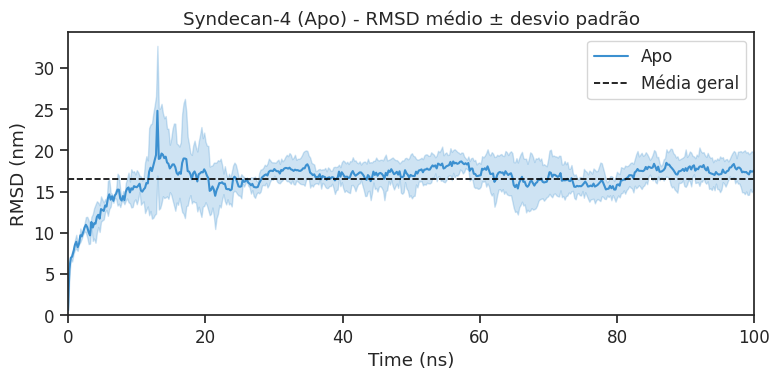

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

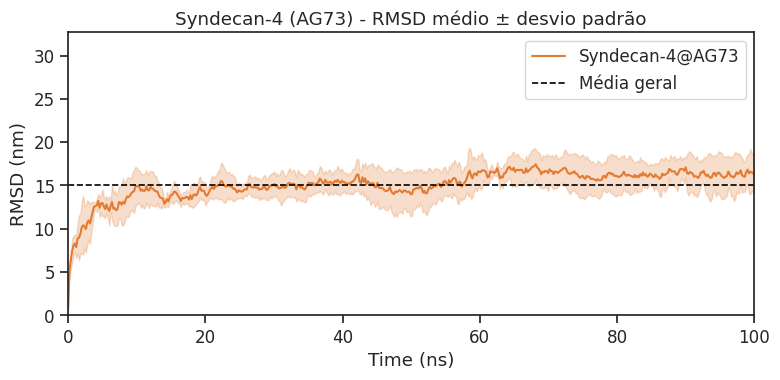

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

# ============================================================
# Gráficos RMSD separados (Apo e AG73) — mesma escala
# ============================================================

# Define escala comum dos eixos
max_time = max(results["apo"]["time_ns"].max(), results["AG73"]["time_ns"].max())
max_rmsd = max(
    (results["apo"]["rmsd_mean"] + results["apo"]["rmsd_std"]).max(),
    (results["AG73"]["rmsd_mean"] + results["AG73"]["rmsd_std"]).max()
)

# ------------------------------------------------------------
# Gráfico 1 - RMSD Apo
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(results["apo"]["time_ns"], results["apo"]["rmsd_mean"], color="#3C90D0", label="Apo")
plt.fill_between(results["apo"]["time_ns"],
                 results["apo"]["rmsd_mean"] - results["apo"]["rmsd_std"],
                 results["apo"]["rmsd_mean"] + results["apo"]["rmsd_std"],
                 alpha=0.25, color="#3C90D0")

# Linha média global (preta, pontilhada)
mean_line_apo = results["apo"]["rmsd_mean"].mean()
plt.axhline(mean_line_apo, color="black", linestyle="--", linewidth=1.2, label="Overall average")

plt.xlabel("Time (ns)")
plt.ylabel("RMSD (Å)")
plt.xlim(0, max_time)
plt.ylim(0, max_rmsd * 1.05)
plt.legend()
plt.tight_layout()

# Salvar e baixar figura antes de mostrar
plt.savefig("RMSD_Apo.png", dpi=600, bbox_inches='tight', transparent=False)
files.download("RMSD_Apo.png")
plt.show()
plt.close()

# ------------------------------------------------------------
# Gráfico 2 - RMSD AG73/Syndecan-4
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(results["AG73"]["time_ns"], results["AG73"]["rmsd_mean"], color="#E37B32", label="AG73/Syndecan-4")
plt.fill_between(results["AG73"]["time_ns"],
                 results["AG73"]["rmsd_mean"] - results["AG73"]["rmsd_std"],
                 results["AG73"]["rmsd_mean"] + results["AG73"]["rmsd_std"],
                 alpha=0.25, color="#E37B32")

# Linha média global (preta, pontilhada)
mean_line_ag73 = results["AG73"]["rmsd_mean"].mean()
plt.axhline(mean_line_ag73, color="black", linestyle="--", linewidth=1.2, label="Overall average")

plt.xlabel("Time (ns)")
plt.ylabel("RMSD (Å)")
plt.xlim(0, max_time)
plt.ylim(0, max_rmsd * 1.0)
plt.legend()
plt.tight_layout()

# Salvar e baixar figura antes de mostrar
plt.savefig("RMSD_AG73.png", dpi=600, bbox_inches='tight', transparent=False)
files.download("RMSD_AG73.png")
plt.show()
plt.close()


In [ ]:
# ------------------------------------------------------------
# Função auxiliar: processa triplicatas e calcula RMSD e RMSF
# ------------------------------------------------------------
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align

def process_condition(pdb_file, traj_files, label):
    print(f"\n[{label}] Preparando análise...")
    print(f"  -> PDB: {pdb_file}")
    print(f"  -> Trajetórias: {traj_files}")

    rmsd_reps = []
    rmsf_reps = []

    for traj in traj_files:
        print(f"     Analisando {traj} ...")
        u = mda.Universe(pdb_file, traj)
        ca = u.select_atoms("name CA")

        # RMSD ------------------------------------------------
        R = rms.RMSD(ca, ca, ref_frame=0).run()
        time_ns = R.rmsd[:, 1] / 1000.0  # ps → ns
        rmsd_vals = R.rmsd[:, 2]/ 10.0
        rmsd_reps.append(rmsd_vals)

        # RMSF ------------------------------------------------
        # Alinhamento à estrutura média antes de calcular
        aligner = align.AlignTraj(u, u, select="name CA", in_memory=True).run()
        avg = ca.positions.copy()
        fluc = []
        for ts in u.trajectory:
            fluc.append((ca.positions - avg) ** 2)
        fluc = np.mean(fluc, axis=0)
        rmsf_vals = np.sqrt(np.mean(fluc, axis=1))
        rmsf_reps.append(rmsf_vals)

    # Padronizar comprimentos (caso as trajetórias tenham durações diferentes)
    min_len_rmsd = min(len(x) for x in rmsd_reps)
    rmsd_matrix = np.vstack([x[:min_len_rmsd] for x in rmsd_reps])
    rmsd_mean = np.mean(rmsd_matrix, axis=0)
    rmsd_std = np.std(rmsd_matrix, axis=0)

    min_len_rmsf = min(len(x) for x in rmsf_reps)
    rmsf_matrix = np.vstack([x[:min_len_rmsf] for x in rmsf_reps])
    rmsf_mean = np.mean(rmsf_matrix, axis=0)
    rmsf_std = np.std(rmsf_matrix, axis=0)
    residues = np.arange(1, len(rmsf_mean) + 1)

    print(f"✅ {label}: RMSD e RMSF calculados ({len(traj_files)} réplicas)")

    return {
        "time_ns": time_ns[:min_len_rmsd],
        "rmsd_mean": rmsd_mean,
        "rmsd_std": rmsd_std,
        "rmsf_mean": rmsf_mean,
        "rmsf_std": rmsf_std,
        "residues": residues
    }


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

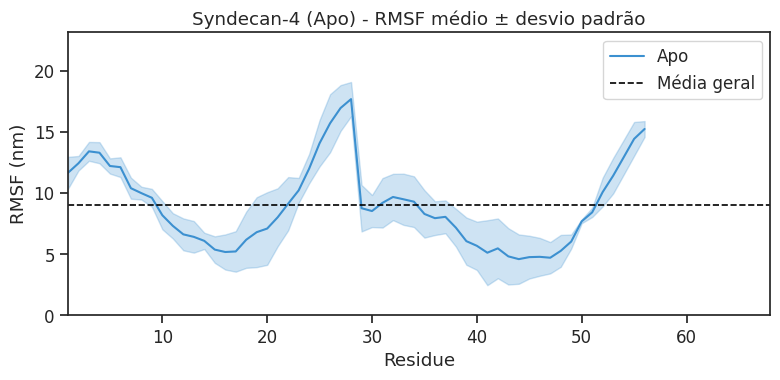

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

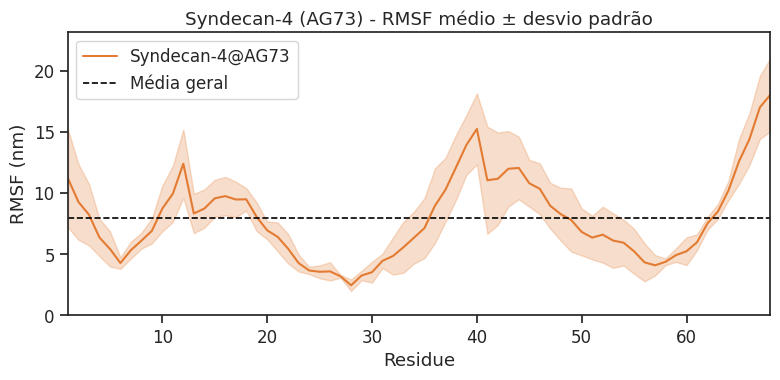

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from MDAnalysis.analysis import align
import MDAnalysis as mda
from google.colab import files

# ------------------------------------------------------------
# RMSF: gráficos separados (mesma escala)
# ------------------------------------------------------------

def ensure_rmsf(results, label, pdb_file=None, traj_files=None):
    """Garante que results[label] tenha rmsf_mean, rmsf_std e residues"""
    if "rmsf_mean" in results[label] and "rmsf_std" in results[label]:
        return  # já existe
    if pdb_file is None or traj_files is None:
        raise ValueError(f"Faltam dados ou arquivos para calcular RMSF de {label}.")

    rmsf_reps = []
    for traj in traj_files:
        u = mda.Universe(pdb_file, traj)
        ca = u.select_atoms("name CA")
        align.AlignTraj(u, u, select="name CA", in_memory=True).run()
        avg = ca.positions.copy()
        fluc = []
        for ts in u.trajectory:
            fluc.append((ca.positions - avg)**2)
        fluc = np.mean(fluc, axis=0)
        rmsf_vals = np.sqrt(np.mean(fluc, axis=1))
        rmsf_reps.append(rmsf_vals)

    # média e desvio padrão
    min_len = min(len(r) for r in rmsf_reps)
    rmsf_matrix = np.vstack([r[:min_len] for r in rmsf_reps])
    results[label]["rmsf_mean"] = np.mean(rmsf_matrix, axis=0)
    results[label]["rmsf_std"] = np.std(rmsf_matrix, axis=0)
    results[label]["residues"] = np.arange(1, len(results[label]["rmsf_mean"]) + 1)

# Garantir RMSF calculado
ensure_rmsf(results, "apo", pdb_file=apo_pdb, traj_files=apo_trajs)
ensure_rmsf(results, "AG73", pdb_file=ag73_pdb, traj_files=ag73_trajs)

# Escalas comuns
max_rmsf = max(
    (results["apo"]["rmsf_mean"] + results["apo"]["rmsf_std"]).max(),
    (results["AG73"]["rmsf_mean"] + results["AG73"]["rmsf_std"]).max()
)
max_residues = max(len(results["apo"]["residues"]), len(results["AG73"]["residues"]))

# ---- APO ----
plt.figure(figsize=(8,4))
plt.plot(results["apo"]["residues"], results["apo"]["rmsf_mean"], color="#3C90D0", label="Apo")
plt.fill_between(results["apo"]["residues"],
                 results["apo"]["rmsf_mean"] - results["apo"]["rmsf_std"],
                 results["apo"]["rmsf_mean"] + results["apo"]["rmsf_std"],
                 alpha=0.25, color="#3C90D0")

# Linha média global (preta, pontilhada)
mean_line_apo = results["apo"]["rmsf_mean"].mean()
plt.axhline(mean_line_apo, color="black", linestyle="--", linewidth=1.2, label="Overall average")

plt.xlabel("Residue")
plt.ylabel("RMSF (Å)")
plt.xlim(1, max_residues)
plt.ylim(0, max_rmsf*1.1)
plt.legend()
plt.tight_layout()
plt.savefig("RMSF_Apo.png", dpi=600, bbox_inches='tight')
files.download("RMSF_Apo.png")
plt.show()
plt.close()

# ---- AG73 ----
plt.figure(figsize=(8,4))
plt.plot(results["AG73"]["residues"], results["AG73"]["rmsf_mean"], color="#E37B32", label="AG73/Syndecan-4")
plt.fill_between(results["AG73"]["residues"],
                 results["AG73"]["rmsf_mean"] - results["AG73"]["rmsf_std"],
                 results["AG73"]["rmsf_mean"] + results["AG73"]["rmsf_std"],
                 alpha=0.25, color="#E37B32")

mean_line_ag73 = results["AG73"]["rmsf_mean"].mean()
plt.axhline(mean_line_ag73, color="black", linestyle="--", linewidth=1.2, label="Overall average")

plt.xlabel("Residue")
plt.ylabel("RMSF (Å)")
plt.xlim(1, max_residues)
plt.ylim(0, max_rmsf*1.1)
plt.legend()
plt.tight_layout()
plt.savefig("RMSF_AG73.png", dpi=600, bbox_inches='tight')
files.download("RMSF_AG73.png")
plt.show()
plt.close()



[Apo] Calculando Raio de Giração ...
  -> APO1.xtc
  -> APO2.xtc
  -> APO3.xtc
✅ Apo: Raio de Giração calculado (3 réplicas)

[AG73] Calculando Raio de Giração ...
  -> AG73Synd1.xtc
  -> AG73Synd2.xtc
  -> AG73Synd3.xtc
✅ AG73: Raio de Giração calculado (3 réplicas)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

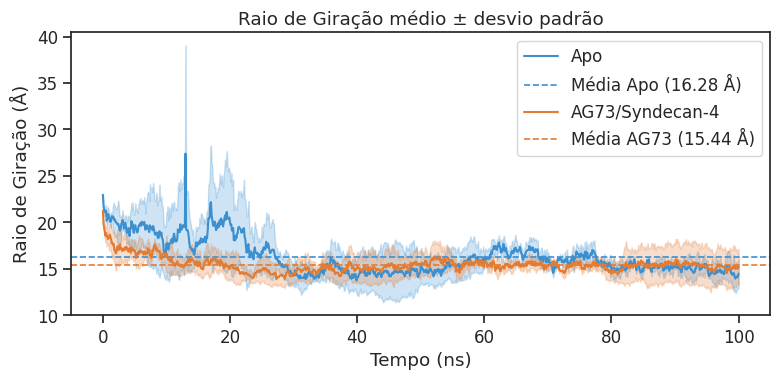

In [ ]:
# ------------------------------
# SEÇÃO 2: Raio de Giração (Rg)
# ------------------------------
def analyze_rg(pdb_file, traj_files, label):
    """
    Calcula Raio de Giração médio ± std para múltiplas réplicas
    """
    print(f"\n[{label}] Calculando Raio de Giração ...")
    rg_reps = []

    for traj in traj_files:
        print(f"  -> {traj}")
        u = mda.Universe(pdb_file, traj)
        protein = u.select_atoms("protein")
        rg_vals = []

        for ts in u.trajectory:
            rg = protein.radius_of_gyration()
            rg_vals.append(rg)

        rg_reps.append(np.array(rg_vals))

    # Ajustar comprimento mínimo entre réplicas
    min_len = min(len(x) for x in rg_reps)
    rg_matrix = np.vstack([x[:min_len] for x in rg_reps])
    rg_mean = np.mean(rg_matrix, axis=0)
    rg_std = np.std(rg_matrix, axis=0)
    time_ns = np.arange(min_len) * (u.trajectory.dt / 1000.0)  # ps -> ns

    print(f"✅ {label}: Raio de Giração calculado ({len(traj_files)} réplicas)")

    return {
        "time_ns": time_ns,
        "rg_mean": rg_mean,
        "rg_std": rg_std
    }

# Exemplo de uso
rg_apo = analyze_rg(apo_pdb, apo_trajs, "Apo")
rg_ag73 = analyze_rg(ag73_pdb, ag73_trajs, "AG73")

# ------------------------------------------------------------
# Plotagem Raio de Giração (salva + baixa)
# ------------------------------------------------------------
plt.figure(figsize=(8,4))

# --- APO ---
plt.plot(rg_apo["time_ns"], rg_apo["rg_mean"], color="#3C90D0", label="Apo")
plt.fill_between(rg_apo["time_ns"],
                 rg_apo["rg_mean"] - rg_apo["rg_std"],
                 rg_apo["rg_mean"] + rg_apo["rg_std"],
                 alpha=0.25, color="#3C90D0")

# Linha média global (pontilhada, preta)
mean_line_apo = np.mean(rg_apo["rg_mean"])
plt.axhline(mean_line_apo, color="#3C90D0", linestyle="--", linewidth=1.2,
            label=f"Overall average Apo ({mean_line_apo:.2f} nm)")

# --- AG73 ---
plt.plot(rg_ag73["time_ns"], rg_ag73["rg_mean"], color="#E37B32", label="AG73/Syndecan-4")
plt.fill_between(rg_ag73["time_ns"],
                 rg_ag73["rg_mean"] - rg_ag73["rg_std"],
                 rg_ag73["rg_mean"] + rg_ag73["rg_std"],
                 alpha=0.25, color="#E37B32")

mean_line_ag73 = np.mean(rg_ag73["rg_mean"])
plt.axhline(mean_line_ag73, color="#E37B32", linestyle="--", linewidth=1.2,
            label=f"Overall average AG73 ({mean_line_ag73:.2f} nm)")

# --- Formatação do gráfico ---
plt.xlabel("Tempo (ns)")
plt.ylabel("Raio de Giração (Å)")
plt.legend()
plt.tight_layout()

# 🔽 Salvar e baixar antes de mostrar
plt.savefig("Raio_de_Giracao.png", dpi=600, bbox_inches='tight')
files.download("Raio_de_Giracao.png")

plt.show()
plt.close()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

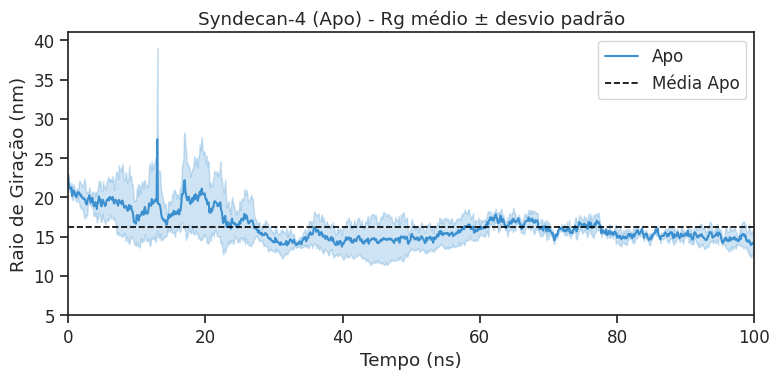

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

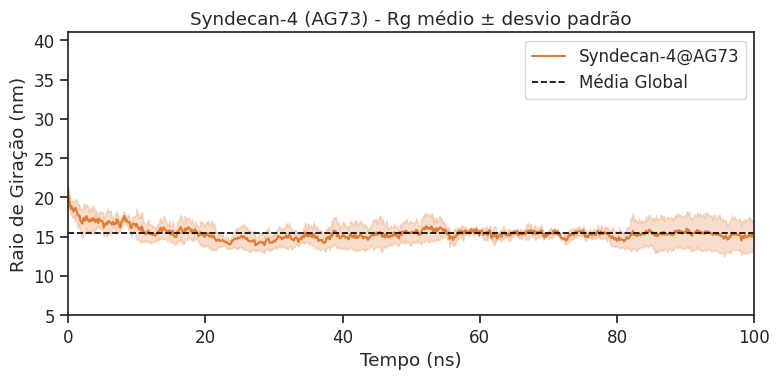

In [ ]:
# ============================================================
# Gráfico Rg - Apo (escala fixa: tempo 0–100 ns, Rg 0–40 Å)
# ============================================================
plt.figure(figsize=(8,4))
plt.plot(rg_apo["time_ns"], rg_apo["rg_mean"], color="#3C90D0", label="Apo")
plt.fill_between(rg_apo["time_ns"],
                 rg_apo["rg_mean"] - rg_apo["rg_std"],
                 rg_apo["rg_mean"] + rg_apo["rg_std"],
                 alpha=0.25, color="#3C90D0")

# Linha média global (pontilhada, preta)
mean_line_apo = np.mean(rg_apo["rg_mean"])
plt.axhline(mean_line_apo, color="black", linestyle="--", linewidth=1.2,
            label=f"Overall average")

plt.xlabel("Tempo (ns)")
plt.ylabel("Raidius de Giration (Å)")


# Escalas fixas
plt.xlim(0, 100)
plt.ylim(5, 39)

plt.legend()
plt.tight_layout()

# 🔽 Salvar e baixar antes de mostrar
plt.savefig("Rg_Apo.png", dpi=600, bbox_inches='tight', transparent=False)
files.download("Rg_Apo.png")

plt.show()
plt.close()


# ============================================================
# Gráfico Rg - AG73/Syndecan-4 (escala fixa: tempo 0–100 ns, Rg 0–40 Å)
# ============================================================
plt.figure(figsize=(8,4))
plt.plot(rg_ag73["time_ns"], rg_ag73["rg_mean"], color="#E37B32", label="AG73/Syndecan-4")
plt.fill_between(rg_ag73["time_ns"],
                 rg_ag73["rg_mean"] - rg_ag73["rg_std"],
                 rg_ag73["rg_mean"] + rg_ag73["rg_std"],
                 alpha=0.25, color="#E37B32")

mean_line_ag73 = np.mean(rg_ag73["rg_mean"])
plt.axhline(mean_line_ag73, color="black", linestyle="--", linewidth=1.2,
            label=f"Overall average")

plt.xlabel("Tempo (ns)")
plt.ylabel("Radius de Giration (Å)")

# Escalas fixas
plt.xlim(0, 100)
plt.ylim(5, 39)

plt.legend()
plt.tight_layout()

# 🔽 Salvar e baixar antes de mostrar
plt.savefig("Rg_AG73.png", dpi=600, bbox_inches='tight', transparent=False)
files.download("Rg_AG73.png")

plt.show()
plt.close()
